# Non-Leaky (Clean) Dataset Pipeline
Pools all images, deduplicates, then stratified re-splits 70/15/15.  
This is the corrected baseline — compare results against `leaky.ipynb`.

## 1. Imports & Config

In [2]:
import os
import re
import csv
import time
import copy
import hashlib
import tracemalloc
import timm
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import imagehash

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize

import onnx
import onnxruntime as ort
from onnxruntime.quantization import quantize_dynamic as onnx_quantize_dynamic, QuantType

# Enable expandable segments to reduce fragmentation
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR      = Path('/home/adityaraut/Documents/research_paper')
DATA_DIR      = BASE_DIR / 'data'
CLEAN_DIR     = BASE_DIR / 'non-leaky'
SPLITS_DIR    = CLEAN_DIR / 'splits'
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

SAVE_DIRS = {
    'convnext_tiny':          CLEAN_DIR / 'convnext_tiny_clean',
    'resnet50':               CLEAN_DIR / 'resnet_clean',
    'mobilenetv3_large_100':  CLEAN_DIR / 'mnv3_large_clean',
}

# ── Hyperparameters (identical to leaky.ipynb) ─────────────────────────────
BATCH_SIZE     = 32
SMALL_BATCH_BS = 8
EPOCHS         = 30
LR             = 1e-4
FREEZE_EPOCHS  = 5
NUM_CLASSES    = 15
IMG_SIZE       = 224
VARIANT        = 'clean'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU
VRAM: 4.0 GB


## 2. Class Name Normalisation

In [3]:
def normalize_class_name(folder_name: str) -> str:
    name = re.sub(r'_(test_valid|test|valid)$', '', folder_name)
    return name.lower().replace(' ', '_')


def build_class_map(split_dir: Path):
    folders  = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
    canonical = sorted(set(normalize_class_name(f) for f in folders))
    class_to_idx = {f: canonical.index(normalize_class_name(f)) for f in folders}
    return class_to_idx, canonical


FOLDER_TO_IDX, CLASS_NAMES = build_class_map(DATA_DIR / 'train')
print('Classes:', CLASS_NAMES)
print('Total classes:', len(CLASS_NAMES))

Classes: ['aphid', 'black_rust', 'blast', 'brown_rust', 'common_root_rot', 'fusarium_head_blight', 'healthy', 'leaf_blight', 'mildew', 'mite', 'septoria', 'smut', 'stem_fly', 'tan_spot', 'yellow_rust']
Total classes: 15


## 3. Data Audit — Duplicate & Leakage Detection

In [4]:
EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

def md5(path: Path) -> str:
    return hashlib.md5(path.read_bytes()).hexdigest()

def phash(path: Path) -> str:
    return str(imagehash.phash(Image.open(path).convert('RGB')))


def collect_all_images(data_dir: Path):
    """Returns list of (path, split, canonical_label, label_idx)."""
    records = []
    for split in ('train', 'valid', 'test'):
        split_dir = data_dir / split
        if not split_dir.exists():
            continue
        for folder in split_dir.iterdir():
            if not folder.is_dir():
                continue
            canonical = normalize_class_name(folder.name)
            if canonical not in CLASS_NAMES:
                print(f'  WARNING: unrecognised folder {folder}')
                continue
            idx = CLASS_NAMES.index(canonical)
            for f in folder.iterdir():
                if f.suffix.lower() in EXTENSIONS:
                    records.append((f, split, canonical, idx))
    return records


print('Collecting all images...')
all_records = collect_all_images(DATA_DIR)
print(f'Total images found: {len(all_records)}')

# ── MD5 hashing ────────────────────────────────────────────────────────────
print('Computing MD5 hashes (exact duplicates)...')
md5_map = {}   # md5_hash → list of (path, split)
for path, split, cls, idx in all_records:
    h = md5(path)
    md5_map.setdefault(h, []).append((path, split))

exact_dupes = {h: v for h, v in md5_map.items() if len(v) > 1}
exact_dupe_images = sum(len(v) - 1 for v in exact_dupes.values())

# ── Cross-split leakage ────────────────────────────────────────────────────
cross_split_leaks = []
for h, entries in exact_dupes.items():
    splits_seen = set(s for _, s in entries)
    if len(splits_seen) > 1:
        cross_split_leaks.append((h, entries))

leaked_images = sum(len(v) for _, v in cross_split_leaks)
leakage_pct   = leaked_images / len(all_records) * 100

print(f'\n{"=" * 50}')
print(f'AUDIT RESULTS')
print(f'{"=" * 50}')
print(f'Total images          : {len(all_records)}')
print(f'Exact duplicate groups: {len(exact_dupes)}')
print(f'Redundant images      : {exact_dupe_images}')
print(f'Cross-split leak groups: {len(cross_split_leaks)}')
print(f'Leaked image instances : {leaked_images}')
print(f'Leakage %             : {leakage_pct:.2f}%')
print(f'{"=" * 50}')

# Save audit report
audit_lines = [
    'DATA AUDIT REPORT',
    f'Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
    '=' * 50,
    f'Total images           : {len(all_records)}',
    f'Exact duplicate groups : {len(exact_dupes)}',
    f'Redundant images       : {exact_dupe_images}',
    f'Cross-split leak groups: {len(cross_split_leaks)}',
    f'Leaked image instances : {leaked_images}',
    f'Leakage %              : {leakage_pct:.2f}%',
    '',
    'Cross-split leaks (sample, first 20):',
]
for h, entries in cross_split_leaks[:20]:
    audit_lines.append(f'  Hash {h[:12]}... → ' +
                       ', '.join(f'{p.name}({s})' for p, s in entries))

(CLEAN_DIR / 'audit_report.txt').write_text('\n'.join(audit_lines))
print('Audit report saved to:', CLEAN_DIR / 'audit_report.txt')

Total images found: 14154
Computing MD5 hashes (exact duplicates)...

AUDIT RESULTS
Total images          : 14154
Exact duplicate groups: 1845
Redundant images      : 3011
Cross-split leak groups: 588
Leaked image instances : 1642
Leakage %             : 11.60%
Audit report saved to: /home/adityaraut/Documents/research_paper/non-leaky/audit_report.txt


In [5]:
# ── Per-split breakdown ────────────────────────────────────────────────────
split_totals = {}
for path, split, cls, idx in all_records:
    split_totals[split] = split_totals.get(split, 0) + 1

# Count how many images per split appear in cross-split leaks
split_leaked = {'train': 0, 'valid': 0, 'test': 0}
for h, entries in cross_split_leaks:
    for path, split in entries:
        split_leaked[split] += 1

print(f'\n{"Split":<10} {"Total":<10} {"Leaked":<10} {"Leak %"}')
print('-' * 40)
for split in ('train', 'valid', 'test'):
    total  = split_totals.get(split, 0)
    leaked = split_leaked.get(split, 0)
    pct    = leaked / total * 100 if total > 0 else 0
    print(f'{split:<10} {total:<10} {leaked:<10} {pct:.2f}%')

# Within-split duplicates (same image appears twice in same split)
within_dupes = {'train': 0, 'valid': 0, 'test': 0}
for h, entries in exact_dupes.items():
    splits_seen = [s for _, s in entries]


Split      Total      Leaked     Leak %
----------------------------------------
train      13104      745        5.69%
valid      300        300        100.00%
test       750        597        79.60%


In [6]:
# Confirm: are the val leaks spread across all classes or concentrated?
class_leak_counts = {cls: 0 for cls in CLASS_NAMES}
for h, entries in cross_split_leaks:
    splits_seen = set(s for _, s in entries)
    if 'valid' in splits_seen:
        for path, split in entries:
            if split == 'valid':
                canonical = normalize_class_name(path.parent.name)
                class_leak_counts[canonical] += 1

print(f'\n{"Class":<30} {"Val images leaked"}')
print('-' * 48)
for cls in CLASS_NAMES:
    print(f'{cls:<30} {class_leak_counts[cls]}')


Class                          Val images leaked
------------------------------------------------
aphid                          20
black_rust                     20
blast                          20
brown_rust                     20
common_root_rot                20
fusarium_head_blight           20
healthy                        20
leaf_blight                    20
mildew                         20
mite                           20
septoria                       20
smut                           20
stem_fly                       20
tan_spot                       20
yellow_rust                    20


## 4. Stratified Re-Split (Deduplicated)

In [7]:
# Keep only one copy of each unique image (by MD5)
seen_hashes = set()
deduped = []
for path, split, cls, idx in all_records:
    h = md5(path)
    if h not in seen_hashes:
        seen_hashes.add(h)
        deduped.append((str(path), idx))

print(f'After deduplication: {len(deduped)} images (removed {len(all_records) - len(deduped)})')

paths_all  = [r[0] for r in deduped]
labels_all = [r[1] for r in deduped]

# 70 / 15 / 15 stratified split
paths_train, paths_tmp, labels_train, labels_tmp = train_test_split(
    paths_all, labels_all, test_size=0.30,
    stratify=labels_all, random_state=42
)
paths_val, paths_test, labels_val, labels_test = train_test_split(
    paths_tmp, labels_tmp, test_size=0.50,
    stratify=labels_tmp, random_state=42
)

print(f'Train: {len(paths_train)} | Val: {len(paths_val)} | Test: {len(paths_test)}')

# Save CSVs — these are released with the paper
for name, paths, labels in [
    ('train', paths_train, labels_train),
    ('val',   paths_val,   labels_val),
    ('test',  paths_test,  labels_test),
]:
    csv_path = SPLITS_DIR / f'{name}.csv'
    with open(csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['path', 'label', 'class_name'])
        for p, l in zip(paths, labels):
            writer.writerow([p, l, CLASS_NAMES[l]])
    print(f'Saved: {csv_path}')

print('Splits saved. DO NOT touch test.csv until final evaluation.')

After deduplication: 11143 images (removed 3011)
Train: 7800 | Val: 1671 | Test: 1672
Saved: /home/adityaraut/Documents/research_paper/non-leaky/splits/train.csv
Saved: /home/adityaraut/Documents/research_paper/non-leaky/splits/val.csv
Saved: /home/adityaraut/Documents/research_paper/non-leaky/splits/test.csv
Splits saved. DO NOT touch test.csv until final evaluation.


## 5. Class Distribution

/tmp/ipykernel_59704/2601151482.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)


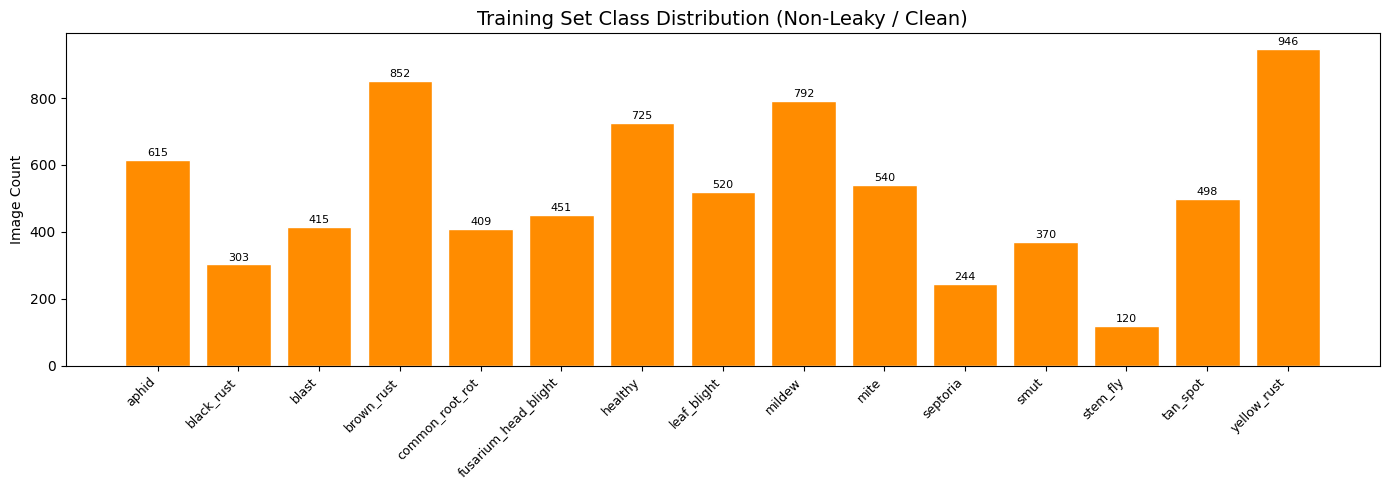

Total train images : 7800
Max class          : yellow_rust (946)
Min class          : stem_fly (120)
Imbalance ratio    : 7.88x


In [8]:
train_counts = np.bincount(labels_train, minlength=NUM_CLASSES)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(CLASS_NAMES, train_counts, color='darkorange', edgecolor='white')
ax.set_title('Training Set Class Distribution (Non-Leaky / Clean)', fontsize=14)
ax.set_ylabel('Image Count')
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
for bar, c in zip(bars, train_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(c), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(CLEAN_DIR / 'class_distribution.png', dpi=150)
plt.show()

print(f'Total train images : {train_counts.sum()}')
print(f'Max class          : {CLASS_NAMES[train_counts.argmax()]} ({train_counts.max()})')
print(f'Min class          : {CLASS_NAMES[train_counts.argmin()]} ({train_counts.min()})')
print(f'Imbalance ratio    : {train_counts.max()/train_counts.min():.2f}x')

## 6. CSV-Based Dataset & DataLoaders

In [9]:
class CSVDataset(Dataset):
    """Reads (path, label) pairs from a CSV produced by the re-split."""

    def __init__(self, csv_path: Path, transform=None):
        self.transform = transform
        self.samples   = []
        with open(csv_path, newline='') as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.samples.append((row['path'], int(row['label'])))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = CSVDataset(SPLITS_DIR / 'train.csv', train_transform)
val_ds   = CSVDataset(SPLITS_DIR / 'val.csv',   val_transform)
test_ds  = CSVDataset(SPLITS_DIR / 'test.csv',  val_transform)

# Class weights from re-split train counts
class_weights = torch.tensor(
    len(train_ds) / (NUM_CLASSES * train_counts.astype(float)),
    dtype=torch.float32
).to(DEVICE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Class weights: {class_weights.cpu().numpy().round(3)}')

Train: 7800 | Val: 1671 | Test: 1672
Class weights: [0.846 1.716 1.253 0.61  1.271 1.153 0.717 1.    0.657 0.963 2.131 1.405
 4.333 1.044 0.55 ]


## 7. Model Factory

In [10]:
def get_model(name: str, num_classes: int) -> nn.Module:
    """Load pretrained model via timm, replace classifier head."""
    if name == 'convnext_tiny':
        # ConvNeXt-Tiny
        m = timm.create_model('convnext_tiny.in12k_ft_in1k', 
                              pretrained=True, num_classes=num_classes)
    elif name == 'resnet50':
        # ResNet50
        m = timm.create_model('resnet50.a1_in1k', 
                              pretrained=True, num_classes=num_classes)
    elif name == 'mobilenetv3_large_100':
        # MobileNetV3-Large
        m = timm.create_model('mobilenetv3_large_100.ra_in1k', 
                              pretrained=True, num_classes=num_classes)
    else:
        raise ValueError(f'Unknown model: {name}')
    return m


def freeze_backbone(model: nn.Module, name: str):
    """Freeze all layers except the model head."""
    for p in model.parameters():
        p.requires_grad = False
        
    if hasattr(model, 'head'):
        for p in model.head.parameters(): p.requires_grad = True
    elif hasattr(model, 'classifier'):
        for p in model.classifier.parameters(): p.requires_grad = True
    elif hasattr(model, 'fc'):
        for p in model.fc.parameters(): p.requires_grad = True


def unfreeze_all(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = True


MODEL_NAMES = ['resnet50', 'mobilenetv3_large_100', 'convnext_tiny']

# param counts
for name in MODEL_NAMES:
    m = get_model(name, NUM_CLASSES)
    total = sum(p.numel() for p in m.parameters()) / 1e6
    print(f'{name:<25} {total:.2f}M params')

resnet50                  23.54M params
mobilenetv3_large_100     4.22M params
convnext_tiny             27.83M params


## 8. Training Loop

In [11]:
def train_model(model_name: str):
    save_dir = SAVE_DIRS[model_name]
    save_dir.mkdir(parents=True, exist_ok=True)

    log_path  = save_dir / f'{model_name}_{VARIANT}_metrics.txt'
    ckpt_path = save_dir / f'{model_name}_{VARIANT}.pth'

    # Determine batch size: 8 for resnet and convnext, 32 for others
    if 'resnet' in model_name or 'convnext' in model_name:
        bs = SMALL_BATCH_BS
    else:
        bs = BATCH_SIZE
    
    # Update DataLoaders for this model
    current_train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True,
                                    num_workers=4, pin_memory=True)
    current_val_loader   = DataLoader(val_ds,   batch_size=bs, shuffle=False,
                                    num_workers=4, pin_memory=True)

    model = get_model(model_name, NUM_CLASSES).to(DEVICE)
    freeze_backbone(model, model_name)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_acc = 0.0
    best_weights = None
    history      = []

    log_lines = [
        f'Model      : {model_name}',
        f'Variant    : {VARIANT}',
        f'Epochs     : {EPOCHS}',
        f'Batch size : {bs}',
        f'LR         : {LR}',
        f'Device     : {DEVICE}',
        f'Started    : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
        '-' * 70,
        f'{"Epoch":<8}{"Train Loss":<14}{"Val Loss":<14}{"Val Acc":<12}{"LR"}',
        '-' * 70,
    ]

    print(f'\n{"="*60}')
    print(f'Training: {model_name.upper()} [{VARIANT}]')
    print(f'{"="*60}')

    try:
        for epoch in range(1, EPOCHS + 1):
            if epoch == FREEZE_EPOCHS + 1:
                unfreeze_all(model)
                optimizer = optim.AdamW(model.parameters(), lr=LR)
                scheduler = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=EPOCHS - FREEZE_EPOCHS
                )
                print(f'  [Epoch {epoch}] Backbone unfrozen.')

            # ── Train ──────────────────────────────────────────────────────────
            model.train()
            train_loss = 0.0
            for imgs, labels in current_train_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(model(imgs), labels)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * imgs.size(0)

            train_loss /= len(train_ds)

            # ── Validate ───────────────────────────────────────────────────────
            model.eval()
            val_loss, correct, total = 0.0, 0, 0
            with torch.no_grad():
                for imgs, labels in current_val_loader:
                    imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                    out = model(imgs)
                    val_loss += criterion(out, labels).item() * imgs.size(0)
                    correct  += (out.argmax(1) == labels).sum().item()
                    total    += labels.size(0)

            val_loss /= len(val_ds)
            val_acc   = correct / total
            current_lr = scheduler.get_last_lr()[0]
            scheduler.step()

            row = {'epoch': epoch, 'train_loss': train_loss,
                   'val_loss': val_loss, 'val_acc': val_acc}
            history.append(row)

            line = (f'{epoch:<8}{train_loss:<14.4f}{val_loss:<14.4f}'
                    f'{val_acc:<12.4f}{current_lr:.6f}')
            log_lines.append(line)
            print(f'  Epoch {epoch:02d}/{EPOCHS} | '
                  f'Train Loss: {train_loss:.4f} | '
                  f'Val Loss: {val_loss:.4f} | '
                  f'Val Acc: {val_acc:.4f}')

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_weights = copy.deepcopy(model.state_dict())

        torch.save({
            'model_name'   : model_name,
            'variant'      : VARIANT,
            'state_dict'   : best_weights,
            'best_val_acc' : best_val_acc,
            'class_names'  : CLASS_NAMES,
        }, ckpt_path)

        log_lines += [
            '-' * 70,
            f'Best Val Acc : {best_val_acc:.4f}',
            f'Saved to     : {ckpt_path}',
            f'Finished     : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
        ]
        log_path.write_text('\n'.join(log_lines))
        print(f'  Best val acc: {best_val_acc:.4f} → saved to {ckpt_path}')

    except RuntimeError as e:
        if 'out of memory' in str(e).lower():
            print(f'  FATAL: CUDA Out of Memory during {model_name} training.')
            torch.cuda.empty_cache()
            raise e
        else:
            raise e

    return model, best_weights, history, ckpt_path


print('Training loop defined.')

Training loop defined.


In [24]:
import pandas as pd
import shutil
import os

df = pd.read_csv('/home/adityaraut/Documents/research_paper/non-leaky/splits/test.csv')
out_dir = '/tmp/calib_images'
os.makedirs(out_dir, exist_ok=True)

for path in df['path']:  # change 'path' to your actual column name
    shutil.copy(path, out_dir)

print(f"Copied {len(df)} images to {out_dir}")

Copied 1672 images to /tmp/calib_images


path,label,class_name
/home/adityaraut/Documents/research_paper/data/train/Blast/blast_239.png,2,blast


In [26]:
import torch
import torch.nn as nn
import timm
import os

class HardSwishPrimitive(nn.Module):
    def forward(self, x):
        return x * torch.clamp(x + 3, 0, 6) / 6

def replace_hardswish(model):
    for name, module in model.named_children():
        if isinstance(module, nn.Hardswish):
            setattr(model, name, HardSwishPrimitive())
        else:
            replace_hardswish(module)
    return model

ckpt_path = '/home/adityaraut/Documents/research_paper/non-leaky/mnv3_large_clean/mobilenetv3_large_100_clean.pth'
ckpt = torch.load(ckpt_path, map_location='cpu')
model = timm.create_model('mobilenetv3_large_100', pretrained=False, num_classes=15)
model.load_state_dict(ckpt['state_dict'])
model.eval()

model = replace_hardswish(model)

dummy = torch.randn(1, 3, 224, 224)
output_path = '/home/adityaraut/Documents/research_paper/non-leaky/mnv3_large_clean/mobilenetv3_large_100_clean_fp32_trt.onnx'

torch.onnx.export(
    model, dummy,
    output_path,
    opset_version=16,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}}
)

print(f"Exported: {os.path.getsize(output_path)/1e6:.2f} MB")

/tmp/ipykernel_15074/1088134911.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location='cpu')


Exported: 16.90 MB


## 9. Train All Models

In [11]:
all_histories  = {}
all_ckpt_paths = {}

for model_name in MODEL_NAMES:
    # Explicitly clear cache before starting a new model
    torch.cuda.empty_cache()
    try:
        model, best_w, history, ckpt = train_model(model_name)
        all_histories[model_name]  = history
        all_ckpt_paths[model_name] = ckpt
        
        # Clean up after training
        del model
        del best_w
    except RuntimeError as e:
        print(f"Skipping {model_name} due to error: {e}")
        continue
    finally:
        torch.cuda.empty_cache()

print('\nAll models processed.')


Training: RESNET50 [clean]
  Epoch 01/30 | Train Loss: 2.5567 | Val Loss: 2.4352 | Val Acc: 0.4931
  Epoch 02/30 | Train Loss: 2.3048 | Val Loss: 2.2477 | Val Acc: 0.5242
  Epoch 03/30 | Train Loss: 2.1250 | Val Loss: 2.1165 | Val Acc: 0.5075
  Epoch 04/30 | Train Loss: 1.9905 | Val Loss: 2.0187 | Val Acc: 0.5200
  Epoch 05/30 | Train Loss: 1.8906 | Val Loss: 1.8787 | Val Acc: 0.5727
  [Epoch 6] Backbone unfrozen.
  Epoch 06/30 | Train Loss: 1.4046 | Val Loss: 1.0242 | Val Acc: 0.7115
  Epoch 07/30 | Train Loss: 1.0433 | Val Loss: 0.8172 | Val Acc: 0.7510
  Epoch 08/30 | Train Loss: 0.8501 | Val Loss: 0.7050 | Val Acc: 0.7768
  Epoch 09/30 | Train Loss: 0.7488 | Val Loss: 0.6543 | Val Acc: 0.7977
  Epoch 10/30 | Train Loss: 0.6635 | Val Loss: 0.6236 | Val Acc: 0.8097
  Epoch 11/30 | Train Loss: 0.5949 | Val Loss: 0.6260 | Val Acc: 0.8091
  Epoch 12/30 | Train Loss: 0.5430 | Val Loss: 0.5772 | Val Acc: 0.8288
  Epoch 13/30 | Train Loss: 0.4942 | Val Loss: 0.5532 | Val Acc: 0.8312
  Epo

## 10. Training Curves

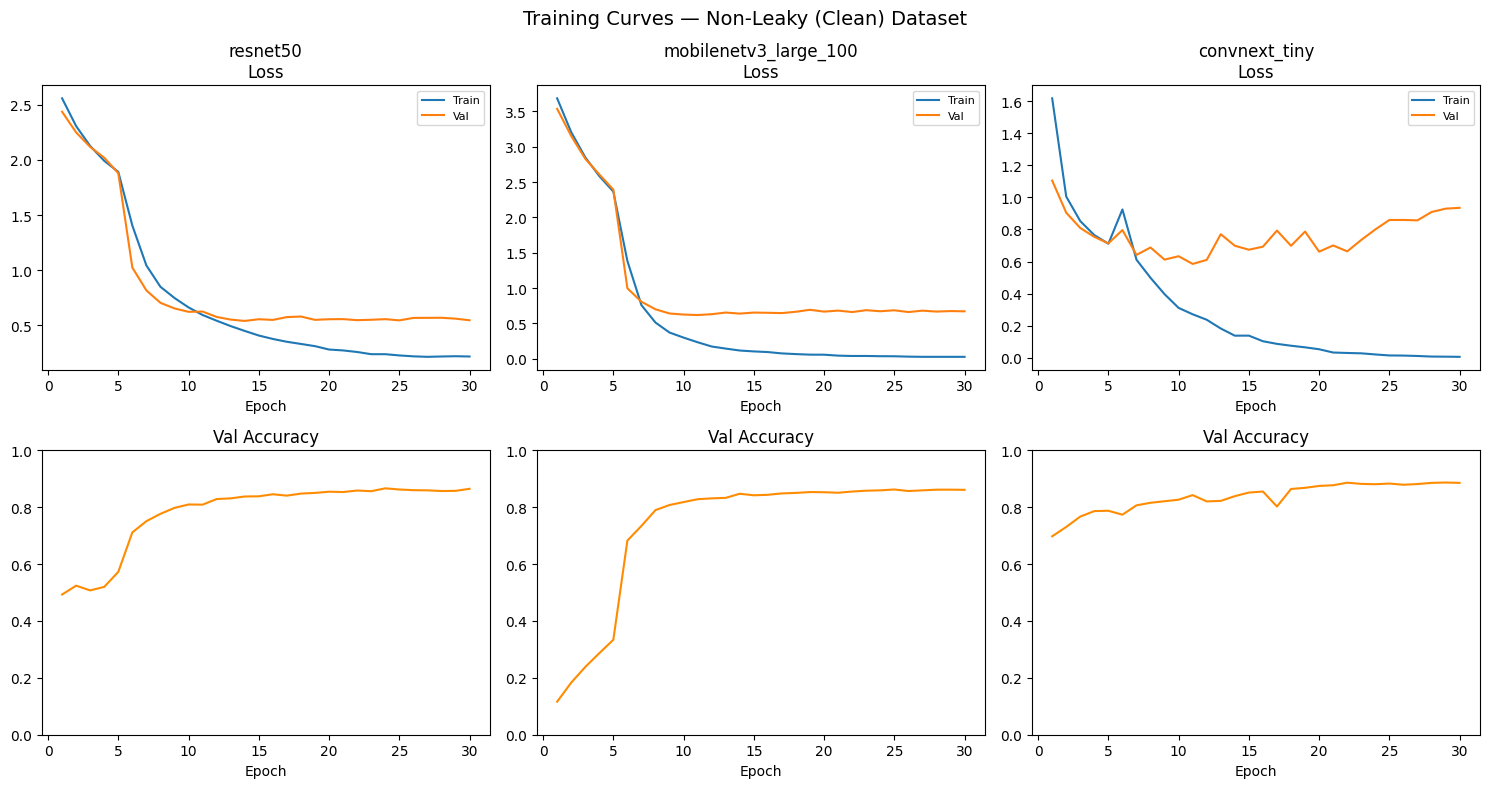

In [12]:
# Load all histories and evaluate best checkpoints from disk on the test set
all_histories = {}
all_ckpt_paths = {}

# Re-populate the paths and histories from disk/previous training
for name in MODEL_NAMES:
    ckpt_path = SAVE_DIRS[name] / f'{name}_{VARIANT}.pth'
    if ckpt_path.exists():
        all_ckpt_paths[name] = ckpt_path
        # Extract history from the metrics file if already trained
        log_path = SAVE_DIRS[name] / f'{name}_{VARIANT}_metrics.txt'
        if log_path.exists():
            content = log_path.read_text()
            # Simple parser for the history lines in the log file
            history = []
            for line in content.split('\n'):
                # Match rows like: 1  0.1234  0.5678  0.8900  0.000100
                match = re.search(r'^(\d+)\s+([\d\.]+)\s+([\d\.]+)\s+([\d\.]+)\s+[\d\.]+', line)
                if match:
                    history.append({
                        'epoch': int(match.group(1)),
                        'train_loss': float(match.group(2)),
                        'val_loss': float(match.group(3)),
                        'val_acc': float(match.group(4))
                    })
            all_histories[name] = history

# Plotting
fig, axes = plt.subplots(2, len(MODEL_NAMES), figsize=(5 * len(MODEL_NAMES), 8))
if len(MODEL_NAMES) == 1: axes = axes.reshape(2, 1)

for col, name in enumerate(MODEL_NAMES):
    if name not in all_histories or not all_histories[name]:
        continue
    h = all_histories[name]
    epochs_range = [r['epoch'] for r in h]
    train_losses = [r['train_loss'] for r in h]
    val_losses   = [r['val_loss'] for r in h]
    val_accs     = [r['val_acc'] for r in h]

    ax = axes[0, col]
    ax.plot(epochs_range, train_losses, label='Train')
    ax.plot(epochs_range, val_losses,   label='Val')
    ax.set_title(f'{name}\nLoss')
    ax.legend(fontsize=8)
    ax.set_xlabel('Epoch')

    ax = axes[1, col]
    ax.plot(epochs_range, val_accs, color='darkorange')
    ax.set_title('Val Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylim(0, 1)

plt.suptitle('Training Curves — Non-Leaky (Clean) Dataset', fontsize=14)
plt.tight_layout()
plt.savefig(CLEAN_DIR / 'training_curves.png', dpi=150)
plt.show()

In [13]:
# Dictionary to store all ONNX variant paths
fp32_paths = {}
fp16_paths = {}
int8_paths = {}

def export_all_variants(model_name: str, ckpt_path: Path):
    save_dir  = SAVE_DIRS[model_name]
    fp32_path = save_dir / f'{model_name}_{VARIANT}_fp32.onnx'
    fp16_path = save_dir / f'{model_name}_{VARIANT}_fp16.onnx'
    int8_path = save_dir / f'{model_name}_{VARIANT}_int8.onnx'

    # 1. Load PyTorch Model
    ckpt  = torch.load(ckpt_path, map_location='cpu')
    model = get_model(model_name, NUM_CLASSES)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()

    # 2. Export FP32 ONNX
    # MobileNetV3 often has better compatibility with lower opsets (like 11)
    opset = 11 if 'mobilenet' in model_name else 17
    
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
    torch.onnx.export(
        model, dummy, str(fp32_path),
        opset_version=opset,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
    )
    
    # 3. Export FP16 ONNX
    from onnxconverter_common import float16
    onnx_model_fp32 = onnx.load(str(fp32_path))
    onnx_model_fp16 = float16.convert_float_to_float16(onnx_model_fp32, keep_io_types=True)
    onnx.save(onnx_model_fp16, str(fp16_path))

    # 4. Export INT8 ONNX (Dynamic Quantization)
    onnx_quantize_dynamic(
        model_input=str(fp32_path),
        model_output=str(int8_path),
        weight_type=QuantType.QUInt8
    )

    # Verification (using FP16 as per request)
    session = ort.InferenceSession(str(fp16_path), providers=['CPUExecutionProvider'])
    test_samples = torch.stack([test_ds[i][0] for i in range(10)])
    with torch.no_grad():
        pt_out = torch.softmax(model(test_samples), dim=1).numpy()
    ort_out = session.run(['output'], {'input': test_samples.numpy()})[0]
    ort_out = np.exp(ort_out) / np.exp(ort_out).sum(axis=1, keepdims=True)
    max_diff = np.abs(pt_out - ort_out).max()

    print(f'  {model_name}:')
    print(f'    FP32: {fp32_path.stat().st_size/1e6:.1f} MB')
    print(f'    FP16: {fp16_path.stat().st_size/1e6:.1f} MB (Max Diff: {max_diff:.2e})')
    print(f'    INT8: {int8_path.stat().st_size/1e6:.1f} MB')
    
    return fp32_path, fp16_path, int8_path

print('Exporting all models to ONNX (FP32, FP16, INT8)...')
for name in MODEL_NAMES:
    ckpt = SAVE_DIRS[name] / f'{name}_{VARIANT}.pth'
    if ckpt.exists():
        f32, f16, i8 = export_all_variants(name, ckpt)
        fp32_paths[name] = f32
        fp16_paths[name] = f16
        int8_paths[name] = i8
    else:
        print(f'Skipping {name}: Checkpoint not found.')

# Update the global onnx_paths variable for compatibility with existing cells
onnx_paths = fp32_paths
print('\nAll exports and path definitions complete.')


Exporting all models to ONNX (FP32, FP16, INT8)...


/tmp/ipykernel_59704/1623606884.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt  = torch.load(ckpt_path, map_location='cpu')
/home/adityaraut/miniconda3/envs/agent

  resnet50:
    FP32: 94.1 MB
    FP16: 47.1 MB (Max Diff: 1.16e-02)
    INT8: 23.7 MB


/home/adityaraut/miniconda3/envs/agent/lib/python3.10/site-packages/onnxconverter_common/float16.py:52: UserWarning: the float32 number 7.812268220568422e-14 will be truncated to 1e-07
  warnings.warn(
/home/adityaraut/miniconda3/envs/agent/lib/python3.10/site-packages/onnxconverter_common/float16.py:70: UserWarning: the float32 number -4.260790938820369e-13 will be truncated to -1e-07
  warnings.warn(
/home/adityaraut/miniconda3/envs/agent/lib/python3.10/site-packages/onnxconverter_common/float16.py:52: UserWarning: the float32 number 4.4183160277135036e-13 will be truncated to 1e-07
  warnings.warn(
/home/adityaraut/miniconda3/envs/agent/lib/python3.10/site-packages/onnxconverter_common/float16.py:70: UserWarning: the float32 number -6.845553583625236e-14 will be truncated to -1e-07
  warnings.warn(
/home/adityaraut/miniconda3/envs/agent/lib/python3.10/site-packages/onnxconverter_common/float16.py:52: UserWarning: the float32 number 9.353726560662468e-13 will be truncated to 1e-07
  

  mobilenetv3_large_100:
    FP32: 16.9 MB
    FP16: 8.5 MB (Max Diff: 3.18e-03)
    INT8: 4.4 MB


/home/adityaraut/miniconda3/envs/agent/lib/python3.10/site-packages/onnxconverter_common/float16.py:52: UserWarning: the float32 number 4.2386719911746695e-08 will be truncated to 1e-07
  warnings.warn(
/home/adityaraut/miniconda3/envs/agent/lib/python3.10/site-packages/onnxconverter_common/float16.py:52: UserWarning: the float32 number 9.346423013312233e-08 will be truncated to 1e-07
  warnings.warn(
/home/adityaraut/miniconda3/envs/agent/lib/python3.10/site-packages/onnxconverter_common/float16.py:52: UserWarning: the float32 number 4.2634805907937334e-08 will be truncated to 1e-07
  warnings.warn(
/home/adityaraut/miniconda3/envs/agent/lib/python3.10/site-packages/onnxconverter_common/float16.py:70: UserWarning: the float32 number -1.5785593276973486e-08 will be truncated to -1e-07
  warnings.warn(
/home/adityaraut/miniconda3/envs/agent/lib/python3.10/site-packages/onnxconverter_common/float16.py:70: UserWarning: the float32 number -5.900918509382791e-08 will be truncated to -1e-07


  convnext_tiny:
    FP32: 111.4 MB
    FP16: 55.8 MB (Max Diff: 7.37e-04)
    INT8: 28.2 MB

All exports and path definitions complete.


## 11. Evaluation on Test Set

In [14]:
def evaluate_model(model_name: str, ckpt_path: Path):
    print(f'Loading checkpoint from: {ckpt_path}')
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    model = get_model(model_name, NUM_CLASSES).to(DEVICE)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()

    # Determine batch size for evaluation
    if 'resnet' in model_name or 'convnext' in model_name:
        bs = SMALL_BATCH_BS
    else:
        bs = BATCH_SIZE
        
    current_test_loader = DataLoader(test_ds, batch_size=bs, shuffle=False,
                                   num_workers=4, pin_memory=True)

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in current_test_loader:
            imgs = imgs.to(DEVICE)
            out  = model(imgs)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc  = (all_preds == all_labels).mean()
    f1   = f1_score(all_labels, all_preds, average='weighted')
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='weighted')
    per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

    labels_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
    try:
        auc = roc_auc_score(labels_bin, all_probs, multi_class='ovr', average='weighted')
    except Exception:
        auc = float('nan')

    cm = confusion_matrix(all_labels, all_preds)

    return {
        'model': model_name, 'accuracy': acc,
        'f1_weighted': f1, 'precision': prec,
        'recall': rec, 'auc': auc,
        'per_class_f1': per_class_f1,
        'conf_matrix': cm,
    }


eval_results = {}
for name in MODEL_NAMES:
    ckpt_path = SAVE_DIRS[name] / f'{name}_{VARIANT}.pth'
    if ckpt_path.exists():
        print(f'\nEvaluating {name} on test set...')
        res = evaluate_model(name, ckpt_path)
        eval_results[name] = res
        print(f'  Acc: {res["accuracy"]:.4f} | F1: {res["f1_weighted"]:.4f} | AUC: {res["auc"]:.4f}')
        torch.cuda.empty_cache()
    else:
        print(f'Warning: Checkpoint not found for {name} at {ckpt_path}')


Evaluating resnet50 on test set...
Loading checkpoint from: /home/adityaraut/Documents/research_paper/non-leaky/resnet_clean/resnet50_clean.pth


/tmp/ipykernel_59704/3547771737.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt  = torch.load(ckpt_path, map_location=DEVICE)


  Acc: 0.8553 | F1: 0.8541 | AUC: 0.9879

Evaluating mobilenetv3_large_100 on test set...
Loading checkpoint from: /home/adityaraut/Documents/research_paper/non-leaky/mnv3_large_clean/mobilenetv3_large_100_clean.pth


/tmp/ipykernel_59704/3547771737.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt  = torch.load(ckpt_path, map_location=DEVICE)


  Acc: 0.8553 | F1: 0.8556 | AUC: 0.9864

Evaluating convnext_tiny on test set...
Loading checkpoint from: /home/adityaraut/Documents/research_paper/non-leaky/convnext_tiny_clean/convnext_tiny_clean.pth


/tmp/ipykernel_59704/3547771737.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt  = torch.load(ckpt_path, map_location=DEVICE)


  Acc: 0.8846 | F1: 0.8838 | AUC: 0.9896


## 12. Confusion Matrices

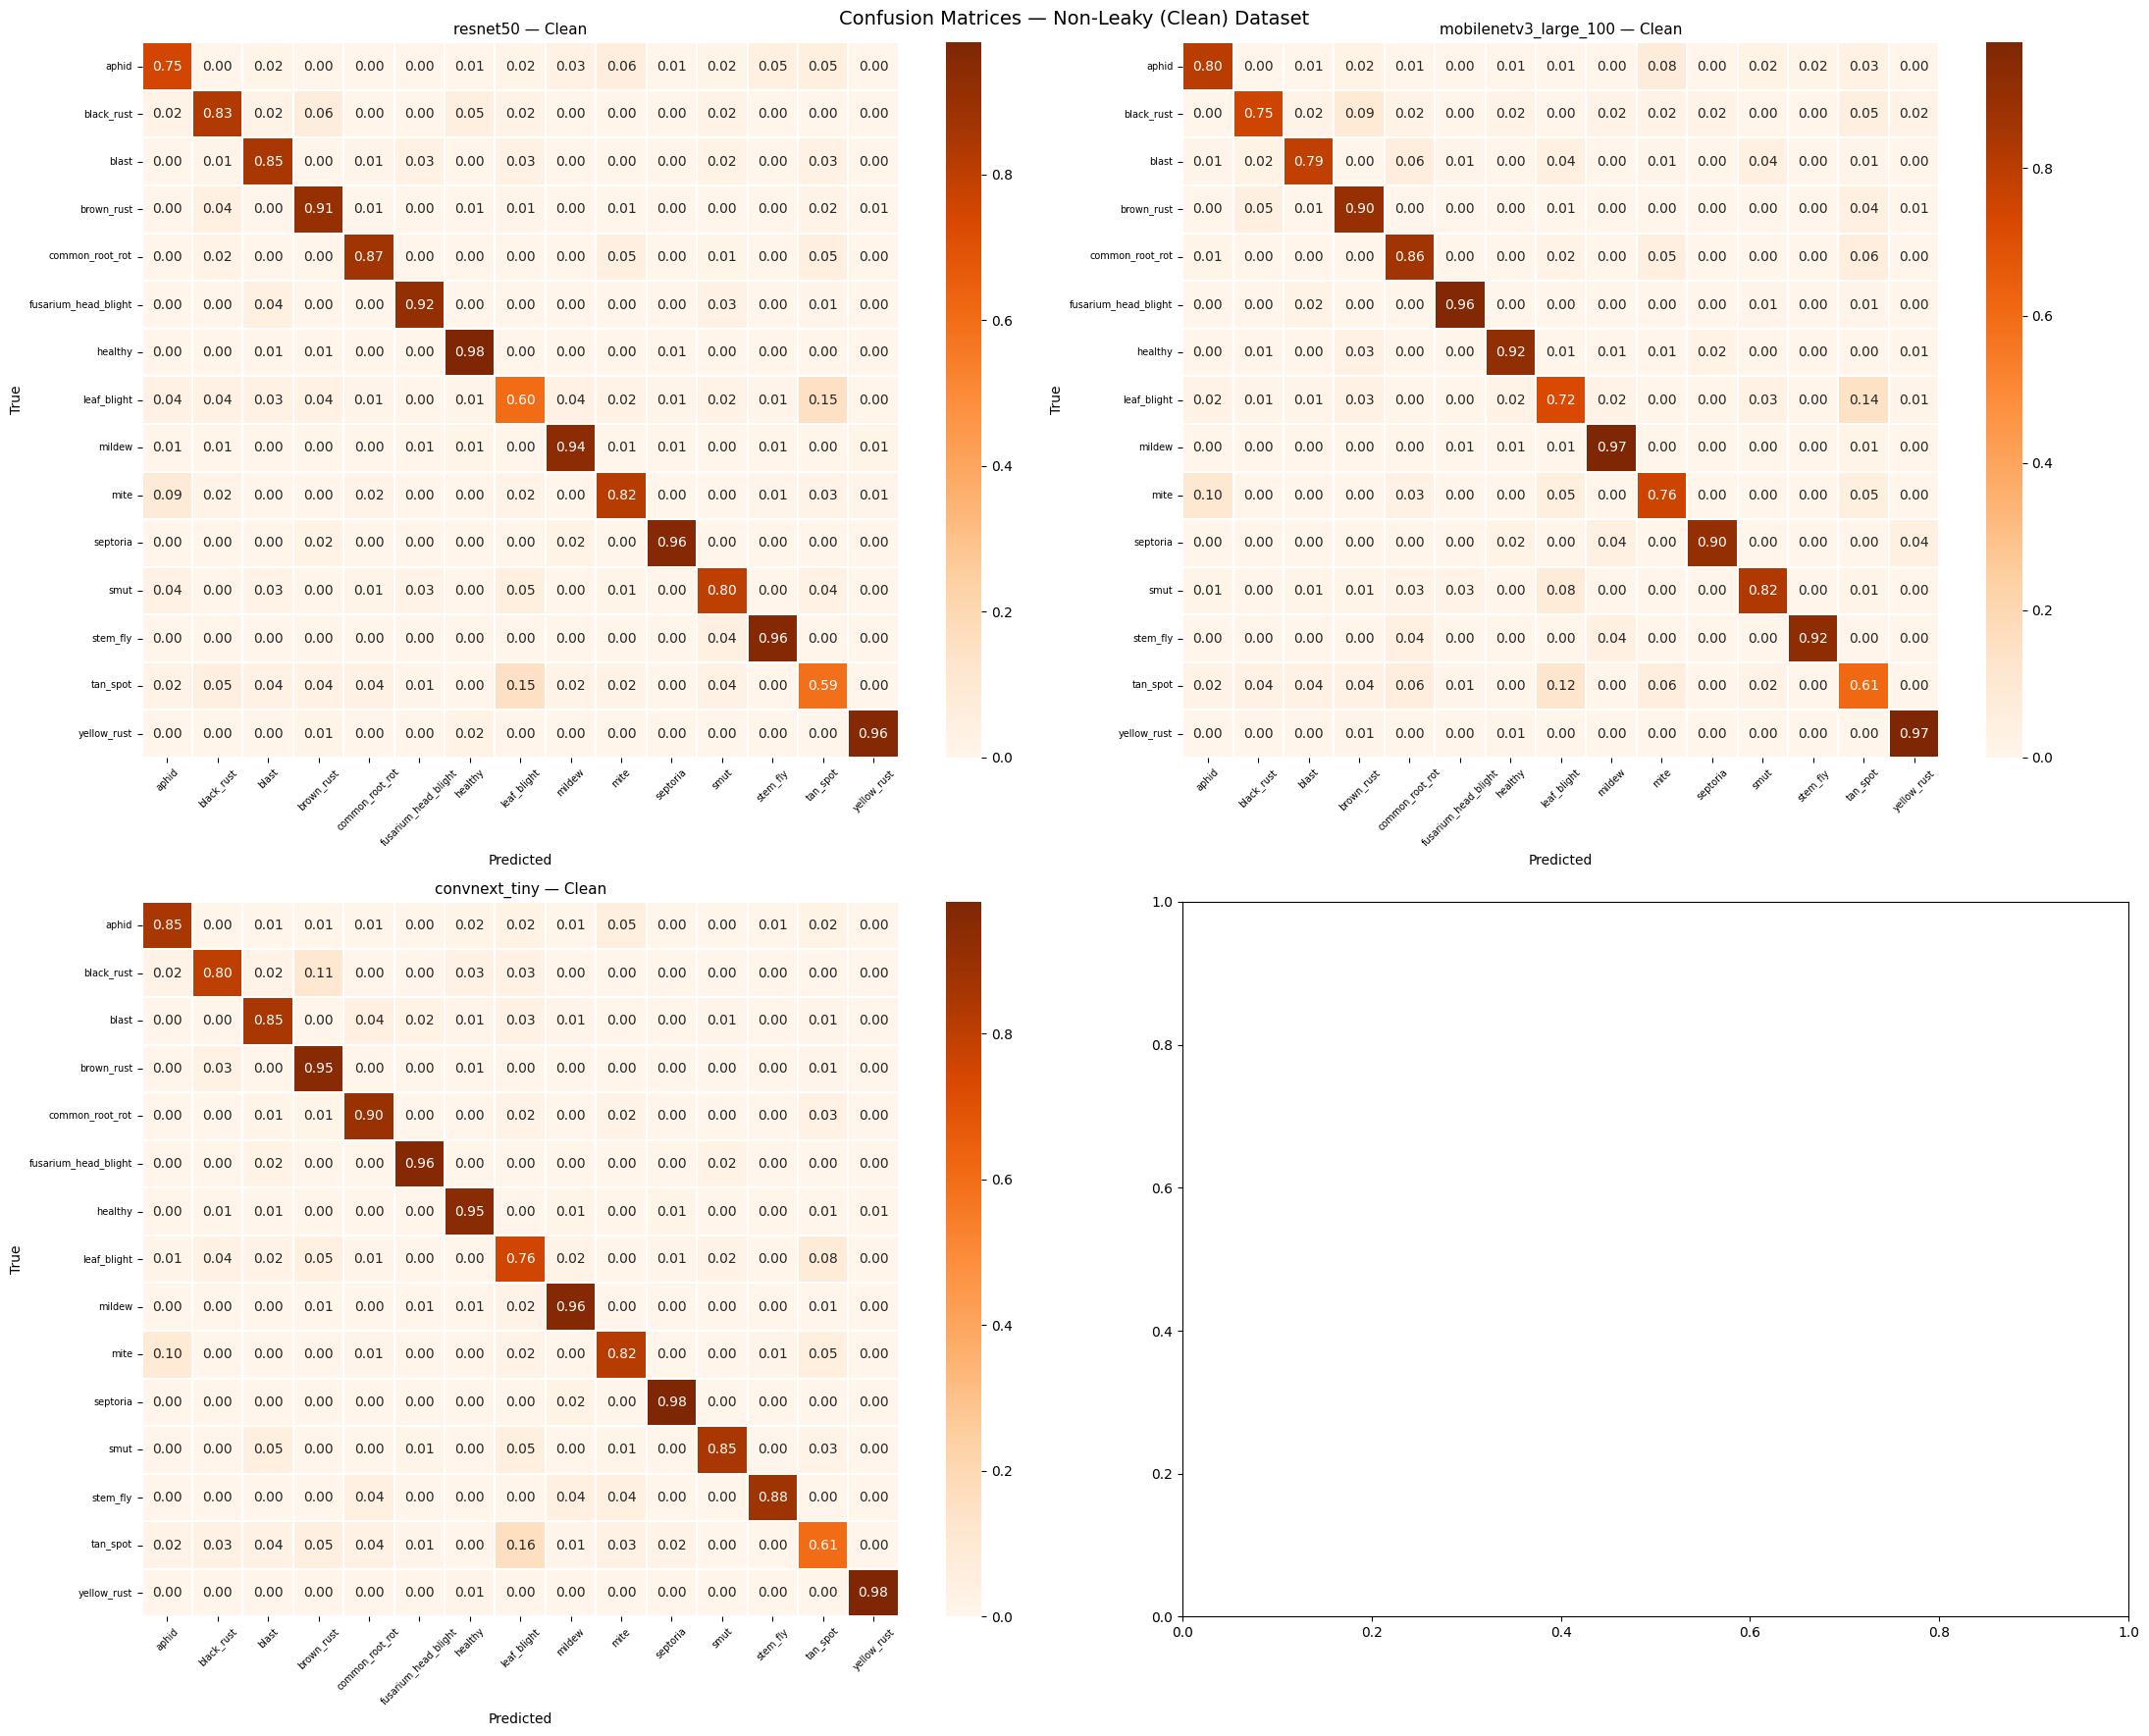

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
axes = axes.flatten()

for i, name in enumerate(MODEL_NAMES):
    cm   = eval_results[name]['conf_matrix']
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, ax=axes[i], annot=True, fmt='.2f', cmap='Oranges',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.3)
    axes[i].set_title(f'{name} — Clean', fontsize=11)
    axes[i].set_ylabel('True')
    axes[i].set_xlabel('Predicted')
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].tick_params(axis='y', rotation=0,  labelsize=7)

plt.suptitle('Confusion Matrices — Non-Leaky (Clean) Dataset', fontsize=14)
plt.tight_layout()
plt.savefig(CLEAN_DIR / 'confusion_matrices.png', dpi=150)
plt.show()

## 13. Per-Class F1 Heatmap

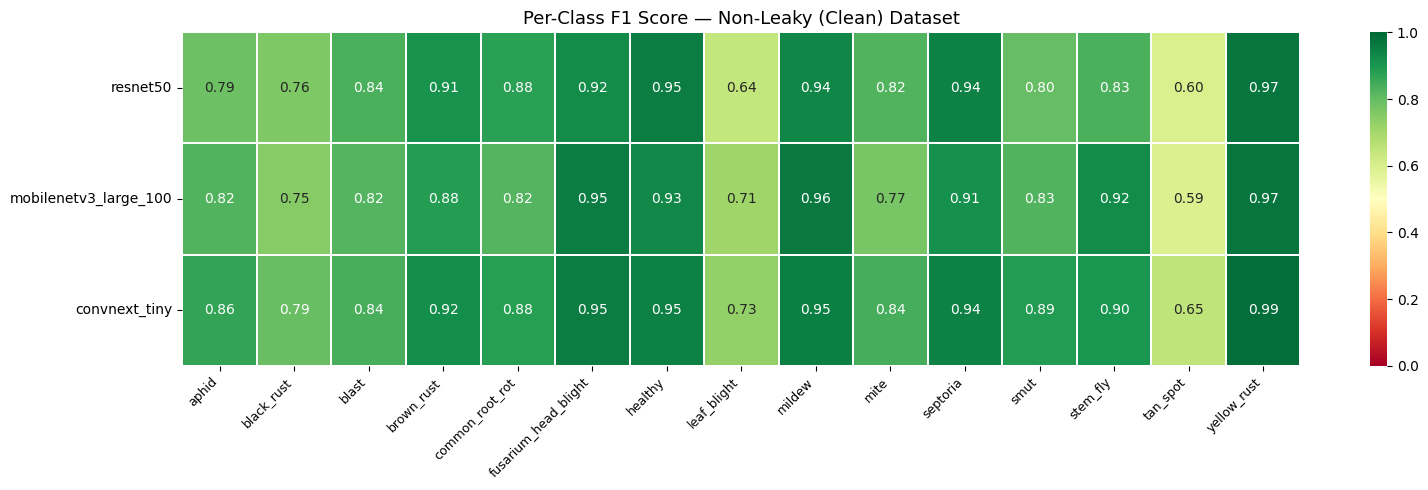

In [16]:
f1_matrix = np.array([eval_results[n]['per_class_f1'] for n in MODEL_NAMES])

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(f1_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=CLASS_NAMES, yticklabels=MODEL_NAMES,
            vmin=0, vmax=1, linewidths=0.3, ax=ax)
ax.set_title('Per-Class F1 Score — Non-Leaky (Clean) Dataset', fontsize=13)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(CLEAN_DIR / 'per_class_f1_heatmap.png', dpi=150)
plt.show()

## 14. Summary Table

In [17]:
print(f'\n{"Model":<25}{"Accuracy":<12}{"F1 (W)":<12}{"Precision":<12}{"Recall":<12}{"AUC"}')
print('-' * 75)
for name in MODEL_NAMES:
    r = eval_results[name]
    print(f'{name:<25}{r["accuracy"]:<12.4f}{r["f1_weighted"]:<12.4f}'
          f'{r["precision"]:<12.4f}{r["recall"]:<12.4f}{r["auc"]:.4f}')

for name in MODEL_NAMES:
    r = eval_results[name]
    log_path = SAVE_DIRS[name] / f'{name}_{VARIANT}_metrics.txt'
    existing = log_path.read_text()
    summary_lines = [
        '',
        '=' * 70,
        'TEST SET RESULTS',
        '=' * 70,
        f'Accuracy  : {r["accuracy"]:.4f}',
        f'F1 (W)    : {r["f1_weighted"]:.4f}',
        f'Precision : {r["precision"]:.4f}',
        f'Recall    : {r["recall"]:.4f}',
        f'AUC       : {r["auc"]:.4f}',
        '',
        'Per-Class F1:',
    ]
    for cls, f1 in zip(CLASS_NAMES, r['per_class_f1']):
        summary_lines.append(f'  {cls:<30} {f1:.4f}')
    log_path.write_text(existing + '\n' + '\n'.join(summary_lines))

print('\nMetrics appended to log files.')


Model                    Accuracy    F1 (W)      Precision   Recall      AUC
---------------------------------------------------------------------------
resnet50                 0.8553      0.8541      0.8548      0.8553      0.9879
mobilenetv3_large_100    0.8553      0.8556      0.8567      0.8553      0.9864
convnext_tiny            0.8846      0.8838      0.8843      0.8846      0.9896

Metrics appended to log files.


## 15. ONNX Export

## 15. ONNX Export FP16

## 16. INT8 Dynamic Quantisation

## 17. Quantised Model Evaluation

In [29]:
def evaluate_onnx(model_name: str, onnx_path: Path):
    session = ort.InferenceSession(str(onnx_path),
                                   providers=['CUDAExecutionProvider',
                                              'CPUExecutionProvider'])
    all_preds, all_labels = [], []

    if 'resnet' in model_name or 'convnext' in model_name:
        bs = SMALL_BATCH_BS
    else:
        bs = BATCH_SIZE

    current_test_loader = DataLoader(test_ds, batch_size=bs, shuffle=False,
                                     num_workers=4, pin_memory=True)

    for imgs, labels in current_test_loader:
        out   = session.run(['output'], {'input': imgs.numpy()})[0]
        preds = out.argmax(axis=1)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = (all_preds == all_labels).mean()
    per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)
    return {'accuracy': acc, 'per_class_f1': per_class_f1}

quant_results = {}
header = f'\n{"Model":<25}{"FP32 Acc":<14}{"FP16 Acc":<14}{"INT8 Acc":<14}{"FP16 Drop":<12}{"INT8 Drop"}'
print(header)
print('-' * len(header))

for name in MODEL_NAMES:
    if name not in fp16_paths or name not in int8_paths:
        continue

    fp32_acc = eval_results[name]['accuracy']

    fp16_res  = evaluate_onnx(name, fp16_paths[name])
    fp16_acc  = fp16_res['accuracy']
    fp16_drop = fp32_acc - fp16_acc

    int8_res  = evaluate_onnx(name, int8_paths[name])
    int8_acc  = int8_res['accuracy']
    int8_drop = fp32_acc - int8_acc

    quant_results[name] = {'fp16': fp16_res, 'int8': int8_res}

    print(f'{name:<25}{fp32_acc:<14.4f}{fp16_acc:<14.4f}{int8_acc:<14.4f}'
          f'{fp16_drop:<12.4f}{int8_drop:.4f}')

    # Update metrics logs with comprehensive quant data
    log_path = SAVE_DIRS[name] / f'{name}_{VARIANT}_metrics.txt'
    existing = log_path.read_text()
    quant_lines = [
        '',
        '=' * 70,
        'QUANTISATION RESULTS',
        '=' * 70,
        f'FP32 Accuracy : {fp32_acc:.4f}',
        f'FP16 Accuracy : {fp16_acc:.4f}  (drop={fp16_drop:+.4f})',
        f'INT8 Accuracy : {int8_acc:.4f}  (drop={int8_drop:+.4f})',
        '',
        'Per-Class F1 across precisions:',
    ]
    for cls, f1_fp32, f1_fp16, f1_int8 in zip(
            CLASS_NAMES,
            eval_results[name]['per_class_f1'],
            fp16_res['per_class_f1'],
            int8_res['per_class_f1']):
        quant_lines.append(
            f'  {cls:<30} FP32={f1_fp32:.3f}  '
            f'FP16={f1_fp16:.3f} (drop={f1_fp32-f1_fp16:+.3f})  '
            f'INT8={f1_int8:.3f} (drop={f1_fp32-int8_drop:+.3f})'
        )
    log_path.write_text(existing + '\n' + '\n'.join(quant_lines))


Model                    FP32 Acc      FP16 Acc      INT8 Acc      FP16 Drop   INT8 Drop
-----------------------------------------------------------------------------------------


/home/adityaraut/miniconda3/envs/agent/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/home/adityaraut/miniconda3/envs/agent/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


resnet50                 0.8553        0.8541        0.7919        0.0012      0.0634


/home/adityaraut/miniconda3/envs/agent/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/home/adityaraut/miniconda3/envs/agent/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


mobilenetv3_large_100    0.8553        0.8541        0.3104        0.0012      0.5449


/home/adityaraut/miniconda3/envs/agent/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/home/adityaraut/miniconda3/envs/agent/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


convnext_tiny            0.8846        0.8846        0.8828        0.0000      0.0018


## 18. INT8 Accuracy Drop — Per-Class Heatmap

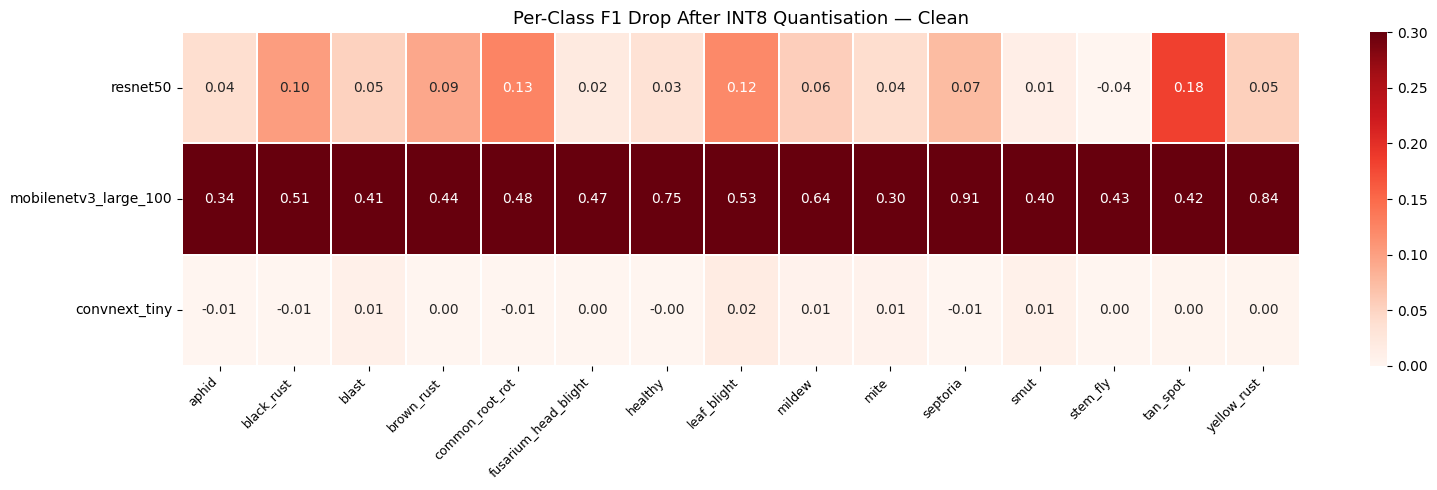


Pipeline complete. All artefacts saved to: /home/adityaraut/Documents/research_paper/non-leaky


In [31]:
# Use the correct dictionary structure from Section 17
fp32_f1_matrix = np.array([eval_results[n]['per_class_f1'] for n in MODEL_NAMES])
int8_f1_matrix = np.array([quant_results[n]['int8']['per_class_f1'] for n in MODEL_NAMES])
drop_matrix    = fp32_f1_matrix - int8_f1_matrix

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(drop_matrix, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=CLASS_NAMES, yticklabels=MODEL_NAMES,
            vmin=0, vmax=0.3, linewidths=0.3, ax=ax)
ax.set_title('Per-Class F1 Drop After INT8 Quantisation — Clean', fontsize=13)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(CLEAN_DIR / 'int8_accuracy_drop.png', dpi=150)
plt.show()

print('\nPipeline complete. All artefacts saved to:', CLEAN_DIR)

/home/adityaraut/miniconda3/envs/agent/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


                model type  latency_ms  throughput_fps  vram_mb    size_mb
             resnet50 FP32   19.842269       50.397462 0.000512  94.073193
             resnet50 FP16   18.838896       53.081666 0.000512  47.058002
             resnet50 INT8   20.178703       49.557200 0.000000  23.703659
mobilenetv3_large_100 FP32    3.430955      291.464031 0.000512  16.876624
mobilenetv3_large_100 FP16    3.504533      285.344693 0.000512   8.472856
mobilenetv3_large_100 INT8   12.644849       79.083584 0.000000   4.432763
        convnext_tiny FP32   31.811838       31.434839 0.000512 111.404476
        convnext_tiny FP16   99.974352       10.002565 0.000512  55.771913
        convnext_tiny INT8   50.935230       19.632777 0.000000  28.225281


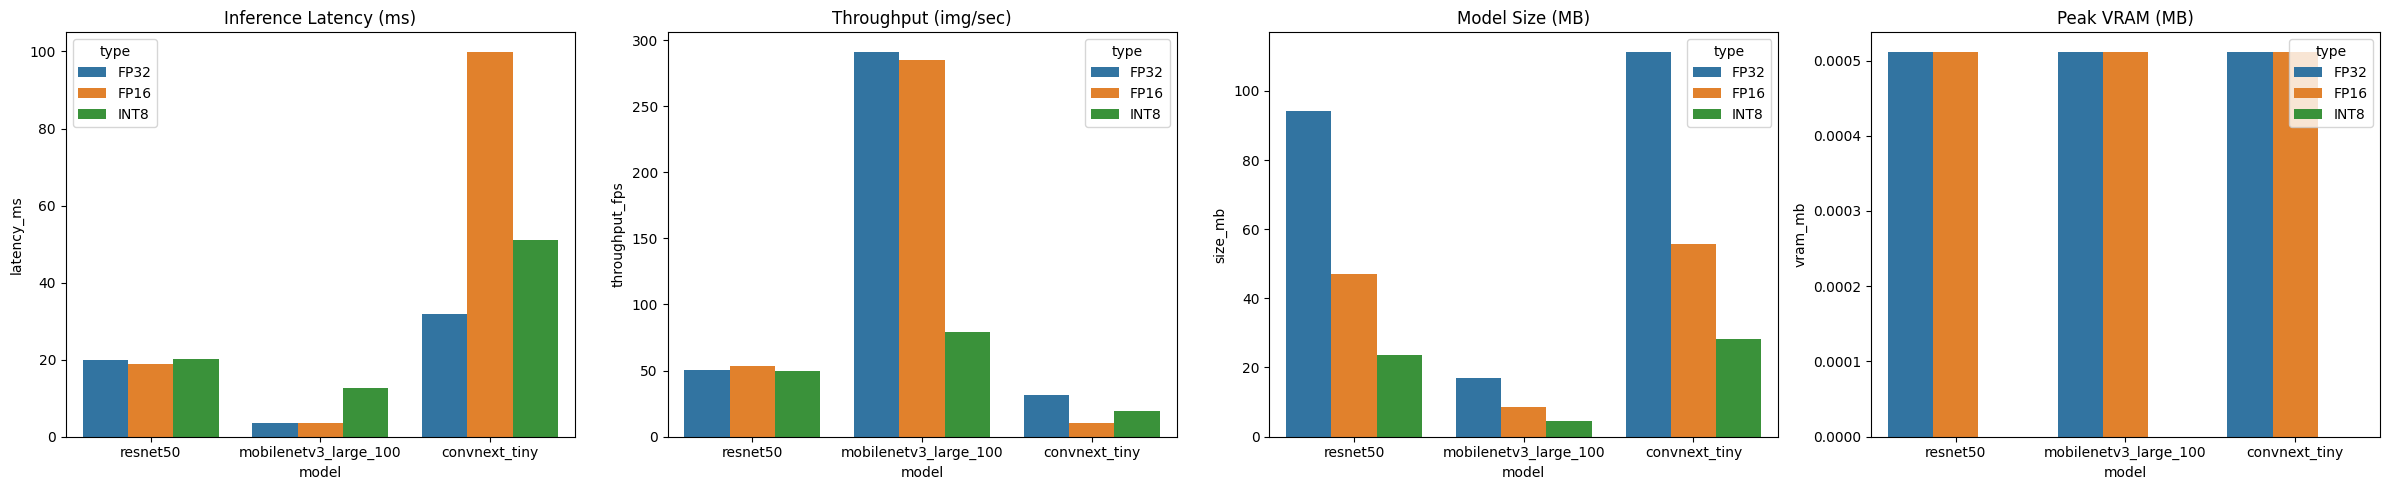

In [27]:
def benchmark_onnx(model_name: str, onnx_path: Path, device='cuda'):
    providers = ['CUDAExecutionProvider', 'CPUExecutionProvider'] if device == 'cuda' else ['CPUExecutionProvider']
    session = ort.InferenceSession(str(onnx_path), providers=providers)
    
    # Warmup
    dummy_input = np.random.randn(1, 3, IMG_SIZE, IMG_SIZE).astype(np.float32)
    for _ in range(10): session.run(['output'], {'input': dummy_input})
    
    # Latency check (100 iterations)
    start_time = time.perf_counter()
    for _ in range(100):
        session.run(['output'], {'input': dummy_input})
    avg_latency = (time.perf_counter() - start_time) / 100 * 1000 # ms
    throughput  = 1000 / avg_latency if avg_latency > 0 else 0
    
    # Memory Check
    if device == 'cuda':
        torch.cuda.reset_peak_memory_stats()
        session.run(['output'], {'input': dummy_input})
        vram_mb = torch.cuda.max_memory_allocated() / 1e6
    else:
        vram_mb = 0.0
        
    return avg_latency, throughput, vram_mb, onnx_path.stat().st_size / 1e6

bench_results = []

for name in MODEL_NAMES:
    # Benchmark FP32
    lat, fps, mem, size = benchmark_onnx(name, onnx_paths[name])
    bench_results.append({'model': name, 'type': 'FP32', 'latency_ms': lat, 'throughput_fps': fps, 'vram_mb': mem, 'size_mb': size})
    
    # Benchmark FP16
    lat, fps, mem, size = benchmark_onnx(name, fp16_paths[name])
    bench_results.append({'model': name, 'type': 'FP16', 'latency_ms': lat, 'throughput_fps': fps, 'vram_mb': mem, 'size_mb': size})
    
    # Benchmark INT8 (Force CPU usage for INT8 dynamic usually)
    lat, fps, mem, size = benchmark_onnx(name, int8_paths[name], device='cpu')
    bench_results.append({'model': name, 'type': 'INT8', 'latency_ms': lat, 'throughput_fps': fps, 'vram_mb': mem, 'size_mb': size})

# Display Results
import pandas as pd
df_bench = pd.DataFrame(bench_results)
print(df_bench.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
sns.barplot(data=df_bench, x='model', y='latency_ms', hue='type', ax=axes[0])
axes[0].set_title('Inference Latency (ms)')

sns.barplot(data=df_bench, x='model', y='throughput_fps', hue='type', ax=axes[1])
axes[1].set_title('Throughput (img/sec)')

sns.barplot(data=df_bench, x='model', y='size_mb', hue='type', ax=axes[2])
axes[2].set_title('Model Size (MB)')

sns.barplot(data=df_bench, x='model', y='vram_mb', hue='type', ax=axes[3])
axes[3].set_title('Peak VRAM (MB)')

plt.tight_layout()
plt.savefig(CLEAN_DIR / 'benchmarking_results.png', dpi=150)
plt.show()

## 20. Performance Benchmarking
Latency, VRAM usage, and Model Size comparison.

## 19. FP16 Quantisation
Creating Float16 versions of the ONNX models for GPU-accelerated inference.

In [ ]:
import torch
import torch.nn as nn
import timm

# ── Patch LayerNorm for TensorRT compatibility ─────────────────────
# ConvNeXt uses LayerNorm in two ways: 
# 1. Standard (spatial/last dim) inside blocks
# 2. Channel-wise (dim 1) when input is [B, C, H, W] in some implementations
# This patched version detects and handles both to avoid broadcast errors.
class LayerNormPrimitive(nn.Module):
    def __init__(self, weight, bias, eps):
        super().__init__()
        self.register_parameter('weight', nn.Parameter(weight.clone()))
        self.register_parameter('bias', nn.Parameter(bias.clone()))
        self.eps = eps

    def forward(self, x):
        # Determine if we normalize over dim 1 (channels) or dim -1 (features)
        # weight.shape[0] tells us the expected number of channels
        if x.ndim == 4 and x.shape[1] == self.weight.shape[0]:
            # [B, C, H, W] normalization
            u = x.mean(1, keepdim=True)
            s = (x - u).pow(2).mean(1, keepdim=True)
            x = (x - u) / torch.sqrt(s + self.eps)
            return self.weight.view(1, -1, 1, 1) * x + self.bias.view(1, -1, 1, 1)
        else:
            # Standard [..., C] normalization
            u = x.mean(-1, keepdim=True)
            s = (x - u).pow(2).mean(-1, keepdim=True)
            x = (x - u) / torch.sqrt(s + self.eps)
            return self.weight * x + self.bias

def replace_layernorm(model):
    for name, module in model.named_children():
        if isinstance(module, nn.LayerNorm):
            new_ln = LayerNormPrimitive(module.weight, module.bias, module.eps)
            setattr(model, name, new_ln)
        else:
            replace_layernorm(module)
    return model

# ── Load checkpoint ────────────────────────────────────────────────
ckpt_path = '/home/adityaraut/Documents/research_paper/non-leaky/convnext_tiny_clean/convnext_tiny_clean.pth'
ckpt = torch.load(ckpt_path, map_location='cpu')
model = timm.create_model('convnext_tiny', pretrained=False, num_classes=15)
model.load_state_dict(ckpt['state_dict'])
model.eval()

# ── Patch ──────────────────────────────────────────────────────────
model = replace_layernorm(model)

# ── Export ─────────────────────────────────────────────────────────
dummy = torch.randn(1, 3, 224, 224)
output_path = '/home/adityaraut/Documents/research_paper/non-leaky/convnext_tiny_clean/convnext_tiny_clean_fp32_trt.onnx'

torch.onnx.export(
    model, dummy,
    output_path,
    opset_version=16,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}}
)

import os
if os.path.exists(output_path):
    print(f"Exported successfully to: {output_path}")
    print(f"File size: {os.path.getsize(output_path)/1e6:.2f} MB")
else:
    print("Export failed.")


/tmp/ipykernel_69741/1449643957.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location='cpu')
/tmp/ipykernel_69741/1449643957.py:20: 

Exported successfully to: /home/adityaraut/Documents/research_paper/non-leaky/convnext_tiny_clean/convnext_tiny_clean_fp32_trt.onnx
File size: 111.44 MB


In [ ]:
import numpy as np
import onnxruntime as ort
import onnxruntime.quantization as quant
from onnxruntime.quantization import CalibrationDataReader, QuantType, QuantFormat
from onnxruntime.quantization.shape_inference import quant_pre_process
from pathlib import Path

# Thresholds to prevent overwriting with poor performing models
# Updated keys to match exactly with MODEL_NAMES mapping
BASELINE_ACCURACY = {
    'resnet50': 0.7900,
    'mobilenetv3_large_100': 0.3100,
    'convnext_tiny': 0.8800
}

class WheatCalibrationDataReader(CalibrationDataReader):
    def __init__(self, dataloader, input_name):
        self.dataloader = dataloader
        self.input_name = input_name
        self.data_iter = iter(self.dataloader)

    def get_next(self):
        try:
            # Assumes dataloader returns (images, labels)
            imgs, _ = next(self.data_iter)
            # Ensure tensor is float32 and correct shape (NCHW)
            return {self.input_name: imgs.numpy().astype(np.float32)}
        except StopIteration:
            return None

    def rewind(self):
        self.data_iter = iter(self.dataloader)

def apply_static_quantization(model_names, save_dirs, variant, val_loader, test_loader):
    print("Executing Static Quantization Pipeline with Safeguards...")
    
    for name in model_names:
        save_dir = Path(save_dirs[name])
        fp32_path = save_dir / f'{name}_{variant}_fp32.onnx'
        temp_int8_path = save_dir / f'{name}_{variant}_int8_temp.onnx'
        final_int8_path = save_dir / f'{name}_{variant}_int8.onnx'
        preprocessed_path = save_dir / f'{name}_{variant}_preprocessed.onnx'
        
        if not fp32_path.exists():
            print(f"Skipping {name}: FP32 source missing at {fp32_path}")
            continue
            
        print(f"  Pre-processing {name}...")
        quant_pre_process(
            input_model=str(fp32_path),
            output_model_path=str(preprocessed_path),
            skip_optimization=False
        )
        
        calib_reader = WheatCalibrationDataReader(val_loader, 'input')
        
        print(f"  Quantizing {name} to INT8 (Static QDQ)...")
        # Added try-except to handle quantization failures (like MobileNetV3 invalid graphs)
        try:
            quant.quantize_static(
                model_input=str(preprocessed_path),
                model_output=str(temp_int8_path),
                calibration_data_reader=calib_reader,
                quant_format=QuantFormat.QDQ, 
                per_channel=True,
                weight_type=QuantType.QInt8,
                activation_type=QuantType.QUInt8
            )
            
            # Validation before overwriting
            print(f"  Validating candidate {name} INT8...")
            # If the model is corrupted (like the MobileNetV3 error), Session will fail here
            session = ort.InferenceSession(str(temp_int8_path), providers=['CPUExecutionProvider'])
            all_preds, all_labels = [], []
            for imgs, labels in test_loader:
                input_data = imgs.numpy().astype(np.float32)
                ort_outs = session.run(['output'], {'input': input_data})[0]
                all_preds.extend(ort_outs.argmax(axis=1))
                all_labels.extend(labels.numpy())
            
            current_acc = (np.array(all_preds) == np.array(all_labels)).mean()
            target_acc = BASELINE_ACCURACY.get(name, 0.0)
            
            if current_acc >= target_acc:
                print(f"  Success: {name} INT8 Accuracy {current_acc:.4f} >= baseline {target_acc:.4f}. Updating model.")
                if final_int8_path.exists():
                    final_int8_path.unlink()
                temp_int8_path.rename(final_int8_path)
            else:
                print(f"  REJECTED: {name} INT8 Accuracy {current_acc:.4f} is lower than baseline {target_acc:.4f}. Keeping old model.")
                if temp_int8_path.exists(): temp_int8_path.unlink()
                
        except Exception as e:
            print(f"  CRITICAL FAILURE for {name}: {str(e)}")
            print(f"  Existing model preserved. Error likely due to incompatible model architecture for Static QDQ.")
            if temp_int8_path.exists(): temp_int8_path.unlink()

        if preprocessed_path.exists():
            preprocessed_path.unlink()

    print("Quantization pipeline complete.")

def evaluate_int8_accuracy(model_names, save_dirs, variant, test_loader):
    print("\nFinal INT8 Model Status on CPU:")
    for name in model_names:
        int8_path = Path(save_dirs[name]) / f'{name}_{variant}_int8.onnx'
        if not int8_path.exists():
            print(f"  {name}: No INT8 model found.")
            continue
        
        try:
            session = ort.InferenceSession(str(int8_path), providers=['CPUExecutionProvider'])
            all_preds, all_labels = [], []
            for imgs, labels in test_loader:
                input_data = imgs.numpy().astype(np.float32)
                ort_outs = session.run(['output'], {'input': input_data})[0]
                all_preds.extend(ort_outs.argmax(axis=1))
                all_labels.extend(labels.numpy())
            
            acc = (np.array(all_preds) == np.array(all_labels)).mean()
            print(f"  {name} Final INT8 Accuracy: {acc:.4f}")
        except Exception:
            print(f"  {name}: Existing INT8 file is corrupted or incompatible.")

# Execution
apply_static_quantization(MODEL_NAMES, SAVE_DIRS, VARIANT, val_loader, test_loader)
evaluate_int8_accuracy(MODEL_NAMES, SAVE_DIRS, VARIANT, test_loader)

Executing Static Quantization Pipeline with Safeguards...
  Pre-processing resnet50...
  Quantizing resnet50 to INT8 (Static QDQ)...
  Validating candidate resnet50 INT8...
  Success: resnet50 INT8 Accuracy 0.8343 >= baseline 0.7900. Updating model.
  Pre-processing mobilenetv3_large_100...
  Quantizing mobilenetv3_large_100 to INT8 (Static QDQ)...
  Validating candidate mobilenetv3_large_100 INT8...
  CRITICAL FAILURE for mobilenetv3_large_100: [ONNXRuntimeError] : 10 : INVALID_GRAPH : Load model from /home/adityaraut/Documents/research_paper/non-leaky/mnv3_large_clean/mobilenetv3_large_100_clean_int8_temp.onnx failed:This is an invalid model. In Node, ("blocks.2.0.se.conv_expand.bias_DequantizeLinear", DequantizeLinear, "", -1) : ("blocks.2.0.se.conv_expand.bias_quantized": tensor(int32),"blocks.2.0.se.conv_expand.bias_quantized_scale": tensor(float),"blocks.2.0.se.conv_expand.bias_quantized_zero_point": tensor(int32),) -> ("blocks.2.0.se.conv_expand.bias",) , Error Unrecognized attr